# ETA Challenge — EDA
Train: 37M rows | Dev: 1.2M rows | Target: `duration_seconds`

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', '{:.2f}'.format)

train = pd.read_parquet('data/train.parquet')
dev   = pd.read_parquet('data/dev.parquet')

print(f'train: {len(train):,} rows')
print(f'dev:   {len(dev):,} rows')
train.head()

train: 36,700,289 rows
dev:   1,230,911 rows


,pickup_zone,dropoff_zone,requested_at,passenger_count,duration_seconds
0,161,141,2023-01-01T00:32:10,1,506.00
1,43,237,2023-01-01T00:55:08,1,379.00
2,48,238,2023-01-01T00:25:04,1,765.00
3,138,7,2023-01-01T00:03:48,0,577.00
4,107,79,2023-01-01T00:10:29,1,650.00


In [34]:
# Schema + dtypes
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36700289 entries, 0 to 36700288
Data columns (total 5 columns):
 #   Column            Dtype  
---  ------            -----  
 0   pickup_zone       int32  
 1   dropoff_zone      int32  
 2   requested_at      object 
 3   passenger_count   int8   
 4   duration_seconds  float64
dtypes: float64(1), int32(2), int8(1), object(1)
memory usage: 875.0+ MB


In [35]:
# Target distribution
train['duration_seconds'].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99])

count   36700289.00
mean         989.40
std          792.30
min           30.00
1%           118.00
5%           221.00
25%          466.00
50%          766.00
75%         1246.00
95%         2581.00
99%         3990.00
max        10799.00
Name: duration_seconds, dtype: float64

In [36]:
# Parse timestamps + extract time features
train['requested_at'] = pd.to_datetime(train['requested_at'])
train['hour']         = train['requested_at'].dt.hour
train['dow']          = train['requested_at'].dt.dayofweek  # 0=Mon
train['month']        = train['requested_at'].dt.month

dev['requested_at'] = pd.to_datetime(dev['requested_at'])
dev['hour']         = dev['requested_at'].dt.hour
dev['dow']          = dev['requested_at'].dt.dayofweek
dev['month']        = dev['requested_at'].dt.month

print('done')

done


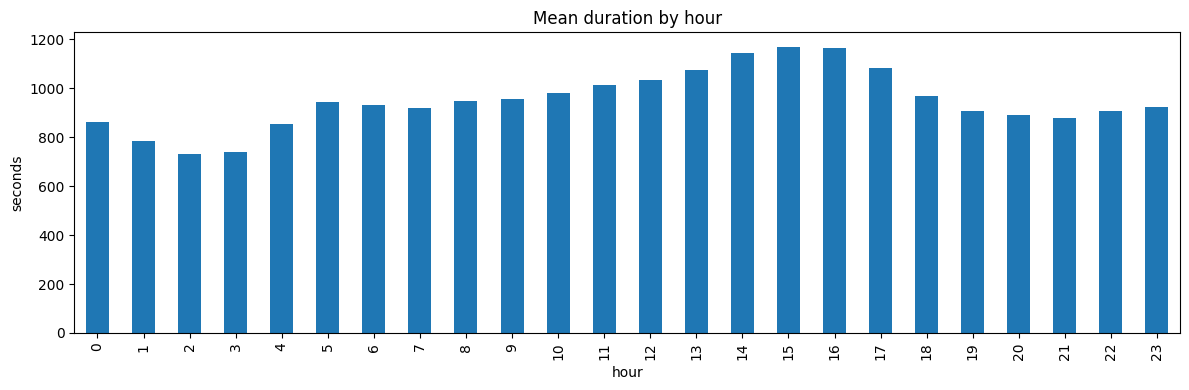

In [37]:
# Mean duration by hour-of-day
train.groupby('hour')['duration_seconds'].mean().plot(kind='bar', figsize=(12,4), title='Mean duration by hour')
plt.ylabel('seconds'); plt.tight_layout(); plt.show()

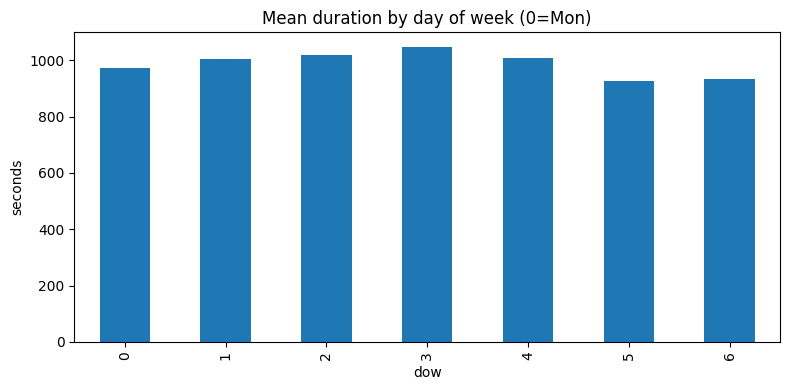

In [38]:
# Mean duration by day-of-week
train.groupby('dow')['duration_seconds'].mean().plot(kind='bar', figsize=(8,4), title='Mean duration by day of week (0=Mon)')
plt.ylabel('seconds'); plt.tight_layout(); plt.show()

In [39]:
# Zone coverage
print('Unique pickup zones: ', train['pickup_zone'].nunique())
print('Unique dropoff zones:', train['dropoff_zone'].nunique())
print('Zones 264/265 (unknown) trips:', (train['pickup_zone'].isin([264,265]) | train['dropoff_zone'].isin([264,265])).sum())

Unique pickup zones:  263
Unique dropoff zones: 262
Zones 264/265 (unknown) trips: 573639


In [40]:
# Passenger count distribution
train['passenger_count'].value_counts().sort_index()

passenger_count
0      557079
1    27972777
2     5356523
3     1318299
4      725224
5      464712
6      305535
7          41
8          72
9          27
Name: count, dtype: int64

In [41]:
# Outlier check — trips > 2h or < 60s
print('> 2h:', (train['duration_seconds'] > 7200).sum())
print('< 60s:', (train['duration_seconds'] < 60).sum())
print('< 60s %:', (train['duration_seconds'] < 60).mean() * 100)

> 2h: 8592
< 60s: 93585
< 60s %: 0.2549979919776654


In [42]:
# Top 20 busiest zone pairs
train.groupby(['pickup_zone','dropoff_zone']).size().sort_values(ascending=False).head(20)

pickup_zone  dropoff_zone
264          264             272497
237          236             249515
236          237             213352
237          237             167425
236          236             160803
161          237             117546
237          161             114783
161          236             101315
142          239              95035
239          142              91667
237          162              90214
239          238              89715
132          230              88593
236          161              87241
141          236              83808
162          237              78371
186          230              77005
138          230              75145
238          239              75056
142          238              74385
dtype: int64

In [43]:
# Zone centroids (precomputed from TLC shapefile)
centroids = pd.read_csv('data/zone_centroids.csv')
centroids.head()

,zone_id,latitude,longitude
0,1,40.69,-74.17
1,2,40.62,-73.83
2,3,40.86,-73.85
3,4,40.72,-73.98
4,5,40.55,-74.19


## Over / Under Prediction Analysis

In [49]:
import pickle, sys
from pathlib import Path
import numpy as np
import pandas as pd

sys.path.insert(0, '.')
from baseline import engineer_features, load_zone_centroids

with open('zone_pair_means.pkl', 'rb') as f:
    zp = pickle.load(f)
with open('zone_pair_hour_means.pkl', 'rb') as f:
    hour_means = pickle.load(f)
with open('model.pkl', 'rb') as f:
    model = pickle.load(f)

centroids = load_zone_centroids()
zp_means, global_mean = zp['means'], zp['global_mean']

# Use the dev df already loaded above (with hour/dow/month parsed)
X_dev = engineer_features(dev, zp_means, hour_means, global_mean, centroids)
y_true = dev['duration_seconds'].to_numpy()
y_pred = np.expm1(model.predict(X_dev))

residuals = y_pred - y_true   # positive = over-predict, negative = under-predict
abs_err   = np.abs(residuals)

dev2 = dev.copy()
dev2['y_pred']   = y_pred
dev2['residual'] = residuals
dev2['abs_err']  = abs_err

print(f"Overall MAE: {abs_err.mean():.1f}s")
print(f"Net bias (mean residual): {residuals.mean():+.1f}s")
print(f"\nOver-predictions  (pred > true): {(residuals > 0).sum():,}  ({(residuals > 0).mean()*100:.1f}%)")
print(f"Under-predictions (pred < true): {(residuals < 0).sum():,}  ({(residuals < 0).mean()*100:.1f}%)")

Overall MAE: 280.4s
Net bias (mean residual): +49.0s

Over-predictions  (pred > true): 769,291  (62.5%)
Under-predictions (pred < true): 461,620  (37.5%)


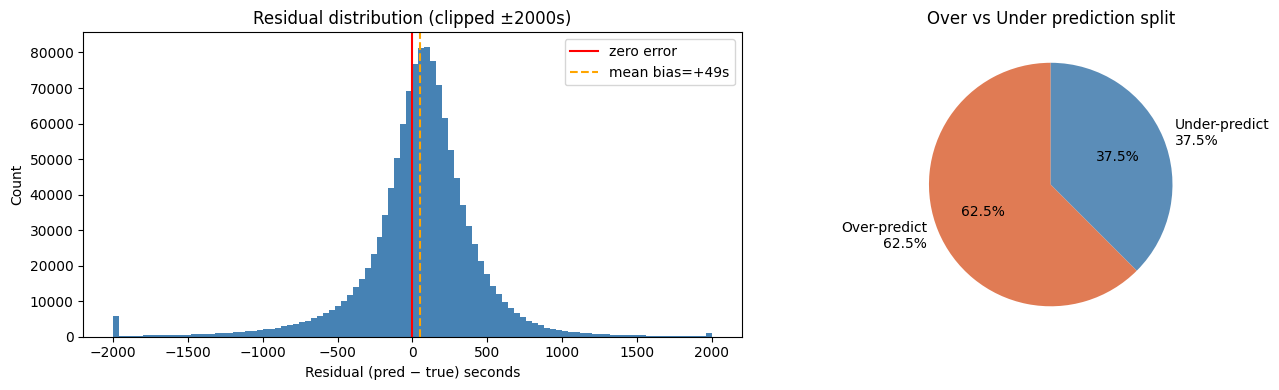

Residual percentiles (all dev):
  P 1: -1394s
  P 5: -594s
  P10: -350s
  P25: -99s
  P50: +78s
  P75: +249s
  P90: +449s
  P95: +605s
  P99: +1049s


In [50]:
# Residual distribution — full picture
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram clipped to [-2000, 2000] for readability
axes[0].hist(residuals.clip(-2000, 2000), bins=100, color='steelblue', edgecolor='none')
axes[0].axvline(0, color='red', lw=1.5, label='zero error')
axes[0].axvline(residuals.mean(), color='orange', lw=1.5, linestyle='--', label=f'mean bias={residuals.mean():+.0f}s')
axes[0].set_xlabel('Residual (pred − true) seconds')
axes[0].set_ylabel('Count')
axes[0].set_title('Residual distribution (clipped ±2000s)')
axes[0].legend()

# Over/under breakdown pie
axes[1].pie(
    [(residuals > 0).sum(), (residuals < 0).sum()],
    labels=[f'Over-predict\n{(residuals>0).mean()*100:.1f}%', f'Under-predict\n{(residuals<0).mean()*100:.1f}%'],
    colors=['#e07b54', '#5b8db8'],
    autopct='%1.1f%%',
    startangle=90,
)
axes[1].set_title('Over vs Under prediction split')

plt.tight_layout()
plt.show()

# Percentile table
pcts = [1, 5, 10, 25, 50, 75, 90, 95, 99]
print("Residual percentiles (all dev):")
for p in pcts:
    print(f"  P{p:2d}: {np.percentile(residuals, p):+.0f}s")

/var/folders/v1/jbtzzvl95x3bw6_nqnp47b4w0000gn/T/ipykernel_85284/2238611839.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bucket_stats = dev2.groupby('dur_bucket', observed=True).apply(lambda g: pd.Series({


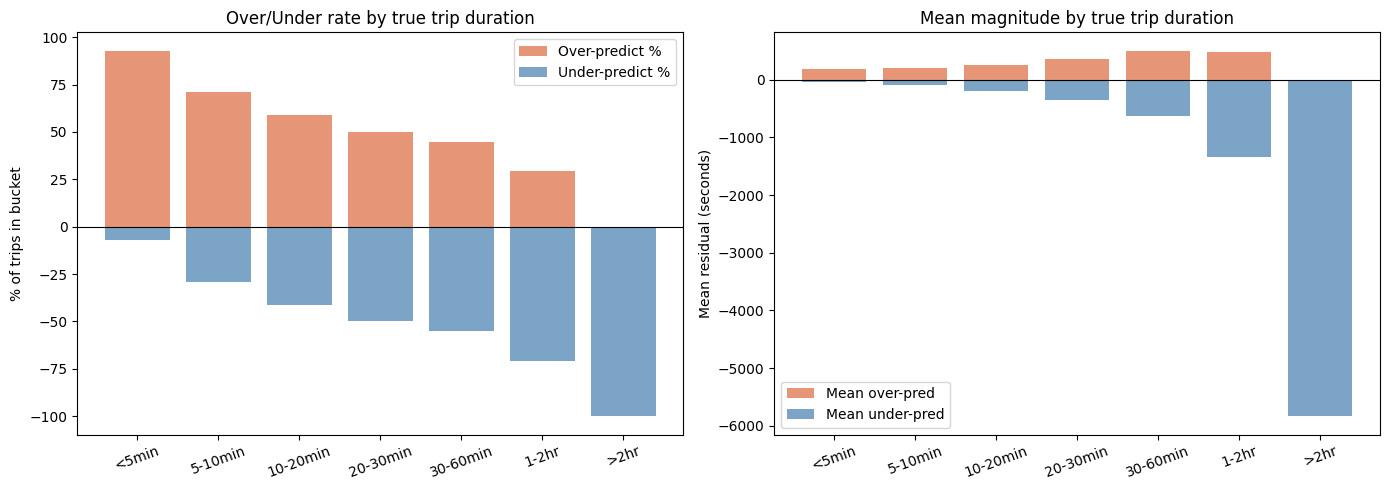

                   n  over_rate%  under_rate%  mean_over  mean_under     mae
dur_bucket                                                                  
<5min      140631.00       92.90         7.10     189.40      -35.10  178.40
5-10min    322398.00       70.90        29.10     199.60      -88.50  167.30
10-20min   427139.00       58.70        41.30     262.70     -190.10  232.80
20-30min   187840.00       50.20        49.80     356.80     -350.40  353.60
30-60min   130922.00       44.80        55.20     507.10     -621.50  570.20
1-2hr       21602.00       29.40        70.60     478.00    -1332.00 1081.00
>2hr          379.00        0.00       100.00       0.00    -5835.60 5835.60


In [46]:
# Over/under rate and mean magnitude by true duration bucket
bins   = [0, 300, 600, 1200, 1800, 3600, 7200, 999999]
labels = ['<5min', '5-10min', '10-20min', '20-30min', '30-60min', '1-2hr', '>2hr']
dev2['dur_bucket'] = pd.cut(dev2['duration_seconds'], bins=bins, labels=labels)

bucket_stats = dev2.groupby('dur_bucket', observed=True).apply(lambda g: pd.Series({
    'n':            len(g),
    'over_rate%':   (g['residual'] > 0).mean() * 100,
    'under_rate%':  (g['residual'] < 0).mean() * 100,
    'mean_over':    g.loc[g['residual'] > 0, 'residual'].mean() if (g['residual'] > 0).any() else 0,
    'mean_under':   g.loc[g['residual'] < 0, 'residual'].mean() if (g['residual'] < 0).any() else 0,
    'mae':          g['abs_err'].mean(),
})).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = range(len(labels))
axes[0].bar(x, bucket_stats['over_rate%'],  label='Over-predict %',  color='#e07b54', alpha=0.8)
axes[0].bar(x, -bucket_stats['under_rate%'], label='Under-predict %', color='#5b8db8', alpha=0.8)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_xticks(list(x)); axes[0].set_xticklabels(labels, rotation=20)
axes[0].set_ylabel('% of trips in bucket'); axes[0].set_title('Over/Under rate by true trip duration')
axes[0].legend()

axes[1].bar(x, bucket_stats['mean_over'],  label='Mean over-pred',  color='#e07b54', alpha=0.8)
axes[1].bar(x, bucket_stats['mean_under'], label='Mean under-pred', color='#5b8db8', alpha=0.8)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xticks(list(x)); axes[1].set_xticklabels(labels, rotation=20)
axes[1].set_ylabel('Mean residual (seconds)'); axes[1].set_title('Mean magnitude by true trip duration')
axes[1].legend()

plt.tight_layout(); plt.show()
print(bucket_stats.to_string())

/var/folders/v1/jbtzzvl95x3bw6_nqnp47b4w0000gn/T/ipykernel_85284/238205472.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hour_stats = dev2.groupby('hour').apply(lambda g: pd.Series({


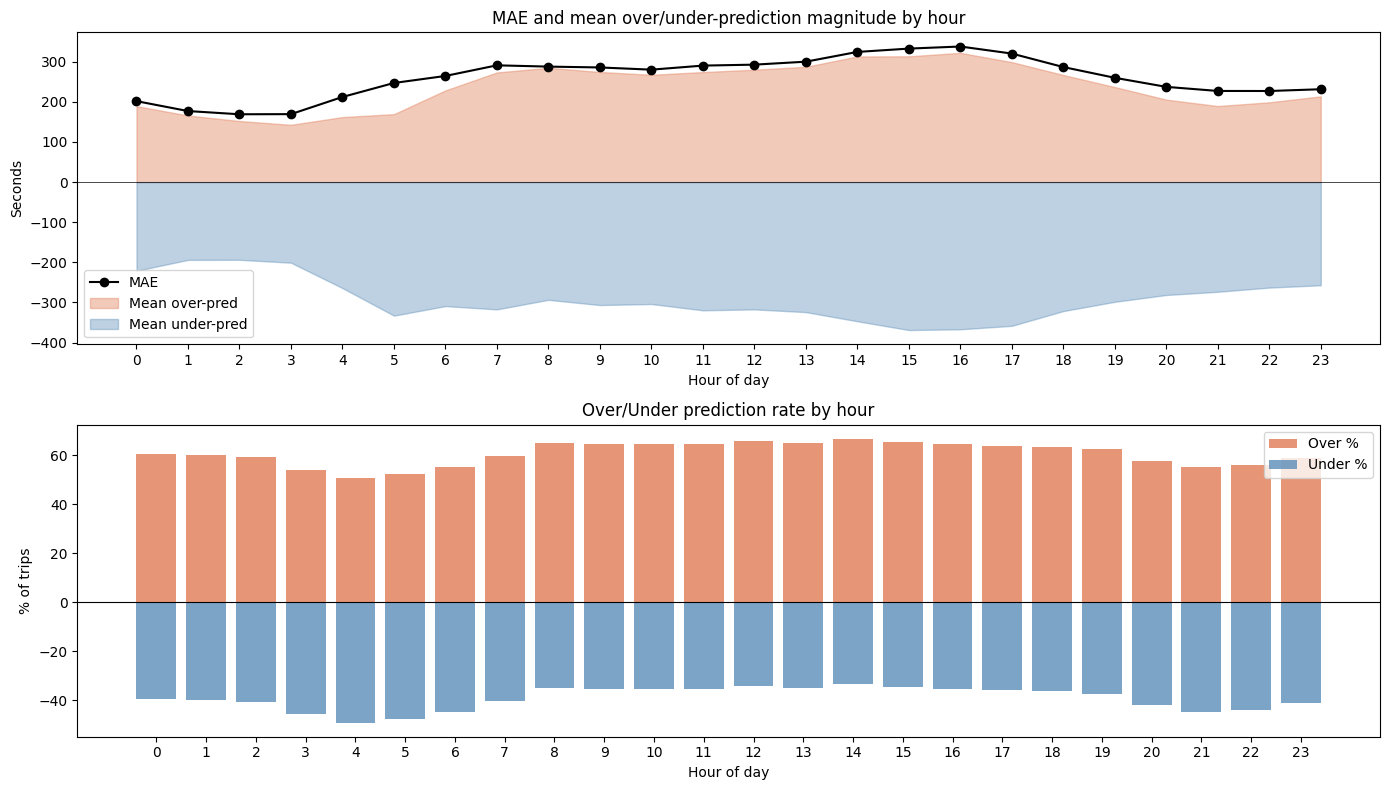

In [47]:
# Over/under rate and MAE by hour of day
hour_stats = dev2.groupby('hour').apply(lambda g: pd.Series({
    'mae':          g['abs_err'].mean(),
    'over_rate%':   (g['residual'] > 0).mean() * 100,
    'under_rate%':  (g['residual'] < 0).mean() * 100,
    'mean_over':    g.loc[g['residual'] > 0, 'residual'].mean() if (g['residual'] > 0).any() else 0,
    'mean_under':   g.loc[g['residual'] < 0, 'residual'].mean() if (g['residual'] < 0).any() else 0,
})).round(1)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

hrs = hour_stats.index
axes[0].plot(hrs, hour_stats['mae'], marker='o', color='black', label='MAE')
axes[0].fill_between(hrs, hour_stats['mean_over'], alpha=0.4, color='#e07b54', label='Mean over-pred')
axes[0].fill_between(hrs, hour_stats['mean_under'], alpha=0.4, color='#5b8db8', label='Mean under-pred')
axes[0].axhline(0, color='black', lw=0.5)
axes[0].set_xticks(list(hrs)); axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Seconds'); axes[0].set_title('MAE and mean over/under-prediction magnitude by hour')
axes[0].legend()

axes[1].bar(hrs, hour_stats['over_rate%'],  color='#e07b54', alpha=0.8, label='Over %')
axes[1].bar(hrs, -hour_stats['under_rate%'], color='#5b8db8', alpha=0.8, label='Under %')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xticks(list(hrs)); axes[1].set_xlabel('Hour of day')
axes[1].set_ylabel('% of trips'); axes[1].set_title('Over/Under prediction rate by hour')
axes[1].legend()

plt.tight_layout(); plt.show()

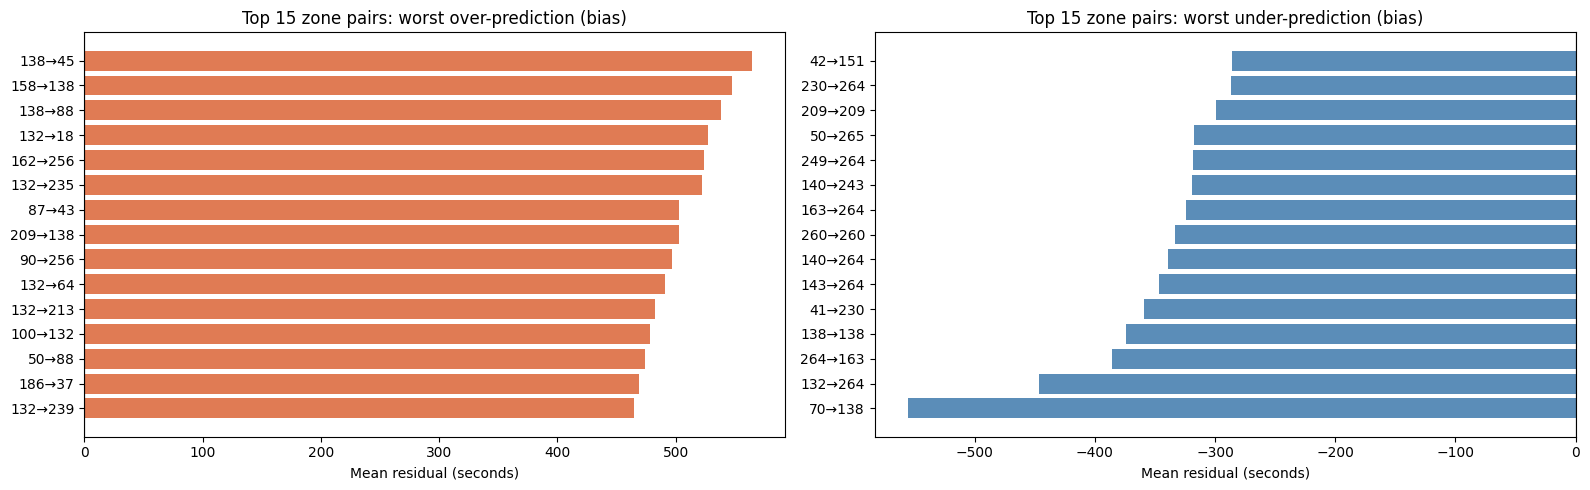


Top over-predicted pairs:
                            n   bias    mae
pickup_zone dropoff_zone                   
138         45             51 564.50 592.00
158         138            50 547.90 599.50
138         88             79 538.10 582.70
132         18             38 527.20 680.60
162         256            49 523.70 621.80
132         235            31 522.20 736.50
87          43             35 502.80 572.30
209         138            36 502.50 706.30
90          256            32 496.60 503.50
132         64             84 491.10 557.10
            213            48 482.90 619.20
100         132           321 478.70 760.40
50          88             32 474.10 480.90
186         37             42 468.70 650.20
132         239           871 465.10 631.60

Top under-predicted pairs:
                            n    bias     mae
pickup_zone dropoff_zone                     
70          138            63 -555.50  591.70
132         264            82 -446.80  901.00
264         1

In [48]:
# Top zone pairs by worst systematic bias
pair_stats = dev2.groupby(['pickup_zone', 'dropoff_zone']).agg(
    n=('residual', 'count'),
    bias=('residual', 'mean'),
    mae=('abs_err', 'mean'),
).query('n >= 30').round(1)

top_over  = pair_stats.nlargest(15, 'bias')[['n', 'bias', 'mae']]
top_under = pair_stats.nsmallest(15, 'bias')[['n', 'bias', 'mae']]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

labels_over  = [f'{pu}→{do}' for pu, do in top_over.index]
labels_under = [f'{pu}→{do}' for pu, do in top_under.index]

axes[0].barh(labels_over[::-1], top_over['bias'].values[::-1], color='#e07b54')
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_xlabel('Mean residual (seconds)'); axes[0].set_title('Top 15 zone pairs: worst over-prediction (bias)')

axes[1].barh(labels_under, top_under['bias'].values, color='#5b8db8')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('Mean residual (seconds)'); axes[1].set_title('Top 15 zone pairs: worst under-prediction (bias)')

plt.tight_layout(); plt.show()

print("\nTop over-predicted pairs:")
print(top_over.to_string())
print("\nTop under-predicted pairs:")
print(top_under.to_string())